In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [3]:
file_path = "/Users/woof2/Downloads/i4-gp/Extended_Predictive_Maintenance_Dataset.csv"

df = pd.read_csv(file_path)

# Basic checks
print("Shape:", df.shape)
df.head()

Shape: (124494, 12)


,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,1/1/2015,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,1/1/2015,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,1/1/2015,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,1/1/2015,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,1/1/2015,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   date     124494 non-null  str  
 1   device   124494 non-null  str  
 2   failure  124494 non-null  int64
 3   metric1  124494 non-null  int64
 4   metric2  124494 non-null  int64
 5   metric3  124494 non-null  int64
 6   metric4  124494 non-null  int64
 7   metric5  124494 non-null  int64
 8   metric6  124494 non-null  int64
 9   metric7  124494 non-null  int64
 10  metric8  124494 non-null  int64
 11  metric9  124494 non-null  int64
dtypes: int64(10), str(2)
memory usage: 11.4 MB


In [5]:
df.describe(include='all')

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
count,124494,124494,124494.000000,1.244940e+05,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000
unique,304,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1/1/2015,S1F0E9EP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1163,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.000851,1.223881e+08,159.492706,9.940897,1.741120,14.222669,260172.657726,0.292528,0.292528,13.013848
std,NaN,NaN,0.029167,7.045933e+07,2179.677781,185.748131,22.908507,15.943028,99151.078547,7.436924,7.436924,275.661220
min,NaN,NaN,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,6.128476e+07,0.000000,0.000000,0.000000,8.000000,221452.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,0.000000,1.227974e+08,0.000000,0.000000,0.000000,10.000000,249799.500000,0.000000,0.000000,0.000000
75%,NaN,NaN,0.000000,1.833096e+08,0.000000,0.000000,0.000000,12.000000,310266.000000,0.000000,0.000000,0.000000


In [6]:
failure_counts = df['failure'].value_counts()

print(failure_counts)
print("\nFailure Rate (%):")
print((failure_counts / len(df)) * 100)

failure
0    124388
1       106
Name: count, dtype: int64

Failure Rate (%):
failure
0    99.914855
1     0.085145
Name: count, dtype: float64


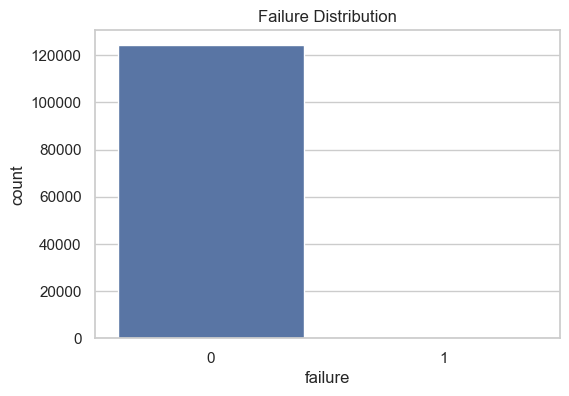

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='failure', data=df)
plt.title("Failure Distribution")
plt.show()

In [8]:
df['date'] = pd.to_datetime(df['date'])

# Extract features
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

df.head()

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9,day,month,weekday
0,2015-01-01,S1F01085,0,215630672,55,0,52,6,407438,0,0,7,1,1,3
1,2015-01-01,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0,1,1,3
2,2015-01-01,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0,1,1,3
3,2015-01-01,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0,1,1,3
4,2015-01-01,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3,1,1,3


In [9]:
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())

Start Date: 2015-01-01 00:00:00
End Date: 2015-11-02 00:00:00


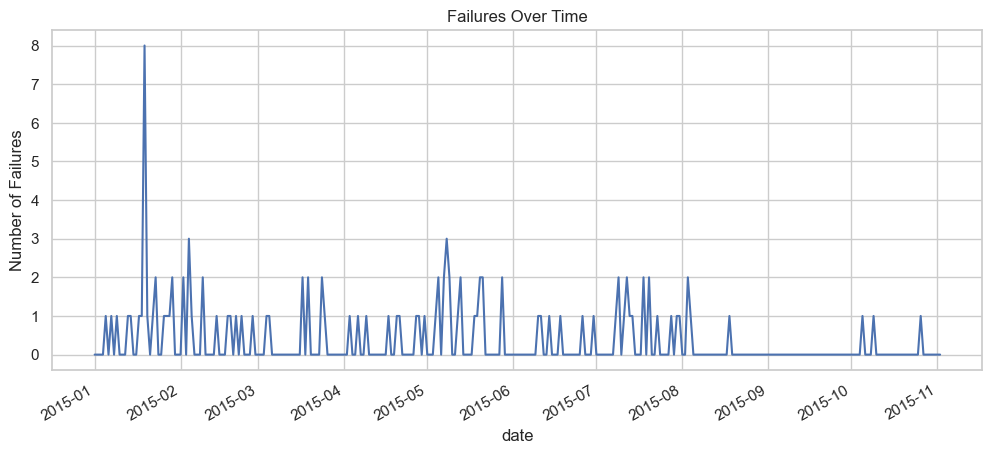

In [10]:
failures_over_time = df.groupby('date')['failure'].sum()

plt.figure(figsize=(12,5))
failures_over_time.plot()
plt.title("Failures Over Time")
plt.ylabel("Number of Failures")
plt.show()

In [11]:
device_failures = df.groupby('device')['failure'].sum().sort_values(ascending=False)

device_failures.head(10)

device
Z1F0LSNZ    1
W1F1230J    1
Z1F0P5D9    1
S1F0L0DW    1
W1F1DQN8    1
S1F0JGJV    1
S1F0JD7P    1
S1F0J5JH    1
Z1F0QH0C    1
S1F0GSHB    1
Name: failure, dtype: int64

In [12]:
failed_devices = device_failures[device_failures > 0]

print("Number of devices with at least one failure:", len(failed_devices))
print("Total devices:", df['device'].nunique())

Number of devices with at least one failure: 106
Total devices: 1169


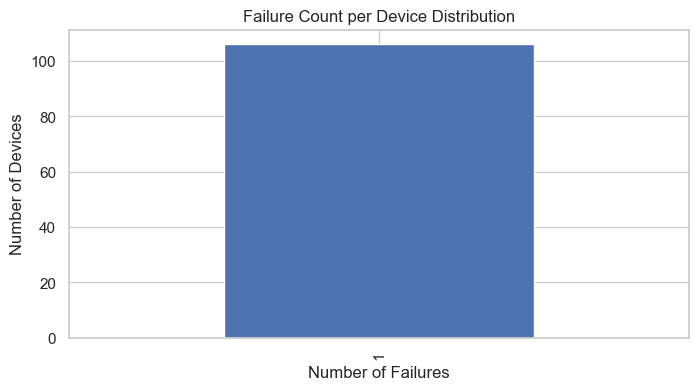

In [13]:
plt.figure(figsize=(8,4))
failed_devices.value_counts().sort_index().plot(kind='bar')
plt.title("Failure Count per Device Distribution")
plt.xlabel("Number of Failures")
plt.ylabel("Number of Devices")
plt.show()

In [14]:
fail_df = df[df['failure'] == 1].copy()

fail_df.head()

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9,day,month,weekday
4885,2015-01-05,S1F0RRB1,1,48467332,64776,0,841,8,39267,56,56,1,5,1,0
6879,2015-01-07,S1F0CTDN,1,184069720,528,0,4,9,387871,32,32,3,7,1,2
8823,2015-01-09,W1F0PNA5,1,136429411,64784,0,406,30,224801,8,8,0,9,1,4
11957,2015-01-13,W1F13SRV,1,188251248,2040,0,0,6,39345,32,32,1,13,1,1
12668,2015-01-14,W1F1230J,1,220461296,0,0,0,14,325125,0,0,0,14,1,2


In [15]:
fail_df.describe()

,date,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9,day,month,weekday
count,106,106.0,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,2015-04-17 21:44:09.056603,1.0,1.271755e+08,4109.433962,3.905660,54.632075,15.462264,258303.481132,30.622642,30.622642,23.084906,15.792453,4.056604,2.132075
min,2015-01-05 00:00:00,1.0,4.527376e+06,0.000000,0.000000,0.000000,3.000000,24.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
25%,2015-02-04 00:00:00,1.0,7.046235e+07,0.000000,0.000000,0.000000,8.000000,230028.750000,0.000000,0.000000,0.000000,9.000000,2.000000,0.250000
50%,2015-04-24 00:00:00,1.0,1.391173e+08,0.000000,0.000000,1.500000,10.000000,267648.500000,0.000000,0.000000,0.000000,18.000000,4.000000,2.000000
75%,2015-06-13 06:00:00,1.0,1.837066e+08,1182.000000,0.000000,18.750000,14.000000,309156.000000,16.000000,16.000000,1.000000,21.000000,6.000000,3.000000
max,2015-10-26 00:00:00,1.0,2.432612e+08,64784.000000,318.000000,1666.000000,91.000000,574599.000000,832.000000,832.000000,1165.000000,31.000000,10.000000,6.000000
std,NaN,0.0,6.940167e+07,12803.747239,31.557213,193.492528,15.547270,103349.308593,117.033610,117.033610,153.449984,8.177457,2.472054,1.773216


In [16]:
normal_df = df[df['failure'] == 0]

comparison = pd.DataFrame({
    "Failure_Mean": fail_df.mean(numeric_only=True),
    "Normal_Mean": normal_df.mean(numeric_only=True)
})

comparison

,Failure_Mean,Normal_Mean
failure,1.000000e+00,0.000000e+00
metric1,1.271755e+08,1.223840e+08
metric2,4.109434e+03,1.561267e+02
metric3,3.905660e+00,9.946040e+00
metric4,5.463208e+01,1.696048e+00
metric5,1.546226e+01,1.422161e+01
metric6,2.583035e+05,2.601743e+05
metric7,3.062264e+01,2.666817e-01
metric8,3.062264e+01,2.666817e-01
metric9,2.308491e+01,1.300527e+01


In [17]:
df = df.sort_values(by=['device', 'date'])

# Create lag features (previous readings)
for col in ['metric1','metric2','metric3','metric4','metric5','metric6','metric7','metric8','metric9']:
    df[f'{col}_lag1'] = df.groupby('device')[col].shift(1)
    df[f'{col}_lag3'] = df.groupby('device')[col].shift(3)

In [18]:
df_lagged = df.dropna().copy()

print(df_lagged.shape)

(120989, 33)


In [19]:
# Rows just BEFORE failure
pre_failure = df_lagged[df_lagged['failure'] == 1]

# Compare lag values
lag_cols = [col for col in df_lagged.columns if 'lag' in col]

comparison_lag = pd.DataFrame({
    "Pre-Failure Mean": pre_failure[lag_cols].mean(),
    "Normal Mean": df_lagged[df_lagged['failure'] == 0][lag_cols].mean()
})

comparison_lag.sort_values(by="Pre-Failure Mean", ascending=False).head(10)

,Pre-Failure Mean,Normal Mean
metric1_lag3,1.261620e+08,1.223920e+08
metric1_lag1,1.252914e+08,1.223716e+08
metric6_lag1,2.577513e+05,2.604843e+05
metric6_lag3,2.570780e+05,2.599051e+05
metric2_lag1,3.203547e+03,1.456967e+02
metric2_lag3,2.939925e+03,1.382065e+02
metric4_lag1,4.770755e+01,1.584863e+00
metric4_lag3,3.563208e+01,1.499433e+00
metric8_lag1,2.315094e+01,2.253584e-01
metric7_lag1,2.315094e+01,2.253584e-01


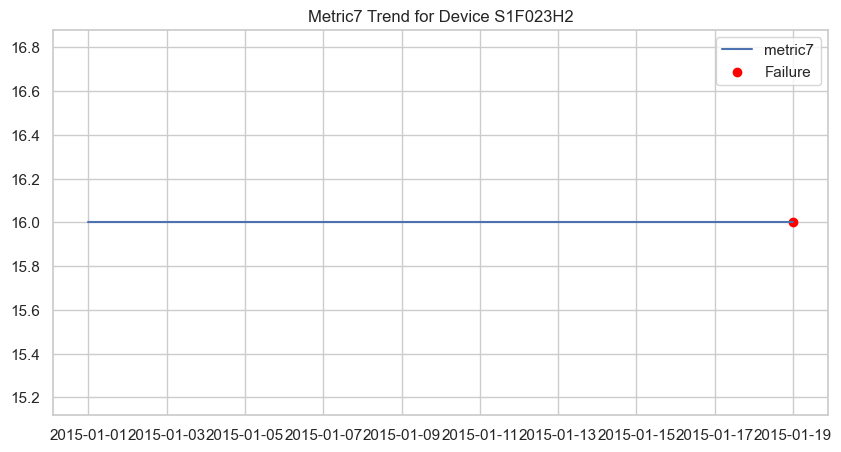

In [20]:
import random

# pick a failed device
device_id = pre_failure['device'].iloc[0]

device_data = df[df['device'] == device_id]

plt.figure(figsize=(10,5))
plt.plot(device_data['date'], device_data['metric7'], label='metric7')
plt.scatter(device_data[device_data['failure']==1]['date'],
            device_data[device_data['failure']==1]['metric7'],
            color='red', label='Failure')

plt.title(f"Metric7 Trend for Device {device_id}")
plt.legend()
plt.show()

In [21]:
# Drop non-useful columns
df_model = df_lagged.copy()

df_model = df_model.drop(columns=['date', 'device'])

X = df_model.drop(columns=['failure'])
y = df_model['failure']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[24177     0]
 [   21     0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24177
           1       0.00      0.00      0.00        21

    accuracy                           1.00     24198
   macro avg       0.50      0.50      0.50     24198
weighted avg       1.00      1.00      1.00     24198



/Users/woof2/Downloads/i4-gp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/woof2/Downloads/i4-gp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/woof2/Downloads/i4-gp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [25]:
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')

model_weighted.fit(X_train, y_train)

y_pred_w = model_weighted.predict(X_test)

print(confusion_matrix(y_test, y_pred_w))
print(classification_report(y_test, y_pred_w))

[[20605  3572]
 [    6    15]]
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     24177
           1       0.00      0.71      0.01        21

    accuracy                           0.85     24198
   macro avg       0.50      0.78      0.46     24198
weighted avg       1.00      0.85      0.92     24198



/Users/woof2/Downloads/i4-gp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
COST_FN = 1000   # Missing a failure (VERY expensive)
COST_FP = 10     # Unnecessary maintenance (moderate)

In [27]:
y_probs = model_weighted.predict_proba(X_test)[:, 1]

In [28]:
import numpy as np

thresholds = np.linspace(0, 1, 100)

costs = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    total_cost = (fn * 1000) + (fp * 10)
    costs.append(total_cost)

# Best threshold
best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Minimum Cost:", costs[best_idx])

Best Threshold: 0.6161616161616162
Minimum Cost: 13510


In [29]:
y_pred_opt = (y_probs >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

[[23726   451]
 [    9    12]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     24177
           1       0.03      0.57      0.05        21

    accuracy                           0.98     24198
   macro avg       0.51      0.78      0.52     24198
weighted avg       1.00      0.98      0.99     24198



In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_probs_rf = rf.predict_proba(X_test)[:, 1]

In [35]:
costs_rf = []

for t in thresholds:
    y_pred_t = (y_probs_rf >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = (fn * 1000) + (fp * 10)
    costs_rf.append(total_cost)

best_idx_rf = np.argmin(costs_rf)
best_threshold_rf = thresholds[best_idx_rf]

print("Best RF Threshold:", best_threshold_rf)
print("Minimum RF Cost:", costs_rf[best_idx_rf])

Best RF Threshold: 0.020202020202020204
Minimum RF Cost: 13960


In [36]:
y_pred_rf = (y_probs_rf >= best_threshold_rf).astype(int)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[24081    96]
 [   13     8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24177
           1       0.08      0.38      0.13        21

    accuracy                           1.00     24198
   macro avg       0.54      0.69      0.56     24198
weighted avg       1.00      1.00      1.00     24198



In [37]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

metric4         0.088318
metric6_lag3    0.066614
metric6_lag1    0.059092
metric6         0.056674
metric1         0.053287
metric7         0.052535
metric2         0.051758
metric1_lag3    0.049455
metric1_lag1    0.042848
metric2_lag1    0.041766
dtype: float64

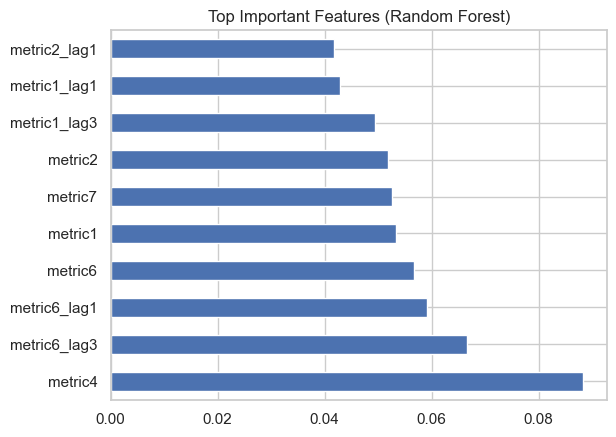

In [38]:
feature_importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Important Features (Random Forest)")
plt.show()